# TT-25 — MLP với Keras: chấm điểm khách hàng tiềm năng mua bảo hiểm ô tô

**Bài toán.** Công ty bảo hiểm có 381.109 khách đang mua bảo hiểm **sức khoẻ**, muốn bán chéo bảo hiểm **ô tô**. Chỉ
~12,3% khách quan tâm. Đội telesales gọi được **3.000 cuộc/ngày**, nên việc cần làm là **xếp hạng** khách theo khả
năng quan tâm và gọi từ trên xuống. Metric: **PR-AUC** (chất lượng xếp hạng trên lớp hiếm) và **Precision@3000**
(trong 3.000 người được gọi, bao nhiêu người quan tâm).

**Câu hỏi chính của bài:** với dữ liệu **bảng**, mạng nơ-ron (MLP Keras) có thắng được cây (LightGBM) không?

**Cấu trúc code.**
* `src/data.py`: tải dữ liệu (kagglehub), chia 70/15/15 có stratify, `Preprocessor` (log1p + StandardScaler + one-hot
  hoặc bảng mã cho Embedding), ma trận cho LightGBM.
* `src/model.py`: `build_mlp()` (Sequential), `build_embedding_mlp()` (Functional, 2 lớp Embedding),
  `compile_model()`, `make_callbacks()` (EarlyStopping + ReduceLROnPlateau + ModelCheckpoint).
* `src/train.py`: mỗi bước của đề là một hàm `run_*()`. Hàm ghi CSV/PNG vào `reports/` và trả về bảng kết quả.

Notebook gọi lại đúng các hàm đó, nên số liệu ở đây và trong `reports/` là một. Trước mỗi ô có phần **Logic code**:
code làm gì và vì sao làm thế.

**3 nguyên tắc đánh giá áp dụng xuyên suốt:**
1. Mọi phép biến đổi (scaler, one-hot, bảng mã embedding) chỉ **fit trên train**.
2. Mọi lựa chọn (epoch dừng, kiến trúc, class_weight, embedding hay one-hot, ngưỡng gọi) chỉ nhìn **tập val**.
3. Tập **test** chỉ dùng để **báo cáo** và so sánh cuối cùng MLP vs LightGBM.

In [1]:
%matplotlib inline
import os, sys, warnings
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve() / "src"))

import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Image, display

import data as D
import model as M
import train as T

tf.config.experimental.enable_op_determinism()   # cung seed -> cung ket qua giua cac lan chay
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
R = T.REPORTS_DIR
print("TensorFlow", tf.__version__, "| Keras", tf.keras.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0 | Keras 3.15.1 | GPU: []


## 1–3. Nạp dữ liệu, chia train/val/test, tiền xử lý

**Logic code (`data.load_raw` → `data.split` → `data.Preprocessor`):**

```python
df = pd.read_csv("data/train.csv").drop(columns="id")      # test.csv cua Kaggle KHONG co nhan -> bo
train_val, test = train_test_split(df, test_size=0.15, stratify=df.Response)
train, val      = train_test_split(train_val, test_size=0.15/0.85, stratify=train_val.Response)
```

* Kaggle chỉ có nhãn ở `train.csv`, nên tự chia **70/15/15**. `stratify` giữ tỉ lệ 12,3% ở cả ba tập; với lớp hiếm
  mà không stratify thì PR-AUC giữa các tập dao động thêm vì lý do ngẫu nhiên.
* Tập **val** dùng cho EarlyStopping và mọi lựa chọn. Không dùng test cho việc đó.

Tiền xử lý (`Preprocessor.fit` chỉ gọi trên train):

| Cột | Biến đổi | Lý do |
|---|---|---|
| `Annual_Premium` | `log1p` → `StandardScaler` | Lệch phải mạnh (max 540k, trung vị 31,7k). Không log thì vài giá trị cực lớn chi phối gradient |
| `Age`, `Vintage`, 4 cột 0/1 | `StandardScaler` | Mạng nơ-ron hội tụ kém khi đầu vào khác thang đo |
| `Vehicle_Age` (3 mức) | one-hot | Ít mức, one-hot rẻ |
| `Region_Code` (53), `Policy_Sales_Channel` (155) | **one-hot** *hoặc* **chỉ số nguyên cho Embedding** | Là **mã**, không phải số: kênh 152 không "lớn hơn" kênh 26. Bước 10 so sánh hai cách |

Hai cách mã hoá tạo ra hai bộ dữ liệu: `data["oh"]` (một ma trận ~220 cột) và `data["emb"]` (ma trận 10 cột + 2 vector
chỉ số). Với Embedding, mã xuất hiện < 10 lần ở train gộp vào chỉ số 0 = "khác", vì vector của mã quá hiếm không học
được gì.

In [2]:
data = T.load()
display(pd.read_csv(R / "chia_du_lieu.csv", index_col=0))
print("Vi du 3 dong goc:"); display(data["frames"]["train"].head(3))
print("Ten cot one-hot (15 cot dau):", data["pre_oh"].feature_names[:15])
print("Vocab embedding: region =", data["pre_emb"].vocab_size("Region_Code"),
      "| channel =", data["pre_emb"].vocab_size("Policy_Sales_Channel"), "(da tinh ca chi so 0 'khac')")

[load] train/val/test = 266,775/57,167/57,167 | so cot one-hot = 216 | so cot dense (embedding) = 10


,so_dong,ti_le_quan_tam
train,"266,775.0000",0.1226
val,"57,167.0000",0.1226
test,"57,167.0000",0.1226


Vi du 3 dong goc:


,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,60,1,48,0,1-2 Year,1,"2,630.0000",103,113,0
1,0,49,1,28,0,1-2 Year,1,"29,706.0000",51,178,0
2,1,55,1,32,1,1-2 Year,1,"38,294.0000",26,213,0


Ten cot one-hot (15 cot dau): ['Age', 'Annual_Premium', 'Vintage', 'Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Damage', 'Vehicle_Age_1-2 Year', 'Vehicle_Age_< 1 Year', 'Vehicle_Age_> 2 Years', 'Region_Code_0', 'Region_Code_1', 'Region_Code_2', 'Region_Code_3', 'Region_Code_4']
Vocab embedding: region = 54 | channel = 107 (da tinh ca chi so 0 'khac')


**Đọc kết quả:** 266.775 / 57.167 / 57.167 dòng, tỉ lệ quan tâm **12,26%** ở cả ba tập (nhờ stratify). Cách one-hot
cho **216 cột** đầu vào: 7 cột số/nhị phân, 3 cột `Vehicle_Age`, 53 cột vùng, 153 cột kênh (2 kênh chỉ có ở val/test
nên không có cột). Cách Embedding chỉ có **10 cột** số thực + 2 chỉ số: vùng có 54 giá trị (53 mã + "khác"), kênh có
**107** giá trị vì 47 kênh có < 10 khách ở train bị gộp vào "khác".

## 1. EDA: tỉ lệ quan tâm theo nhóm

**Logic code (`run_eda`):** `groupby(cot)[Response].agg(size, mean)`: tỉ lệ quan tâm chính là trung bình của nhãn 0/1.
Tuổi được chia thành nhóm bằng `pd.cut`. Đường nét đứt trên biểu đồ là tỉ lệ chung 12,3%. Hàm cũng vẽ phân phối
`Annual_Premium` trước/sau `log1p` để kiểm tra độ lệch.

**Câu hỏi rò rỉ:** `Previously_Insured` mạnh đến mức nghi ngờ. Đề đã kết luận là **không** rò rỉ: khách đã có bảo
hiểm xe hay chưa là thông tin biết **trước** khi gọi, không phải hệ quả của nhãn. Bảng chéo với `Vehicle_Damage` để
xem hai biến mạnh nhất phối hợp thế nào.

[eda] Previously_Insured=1: 0.090% quan tam | =0: 22.5%


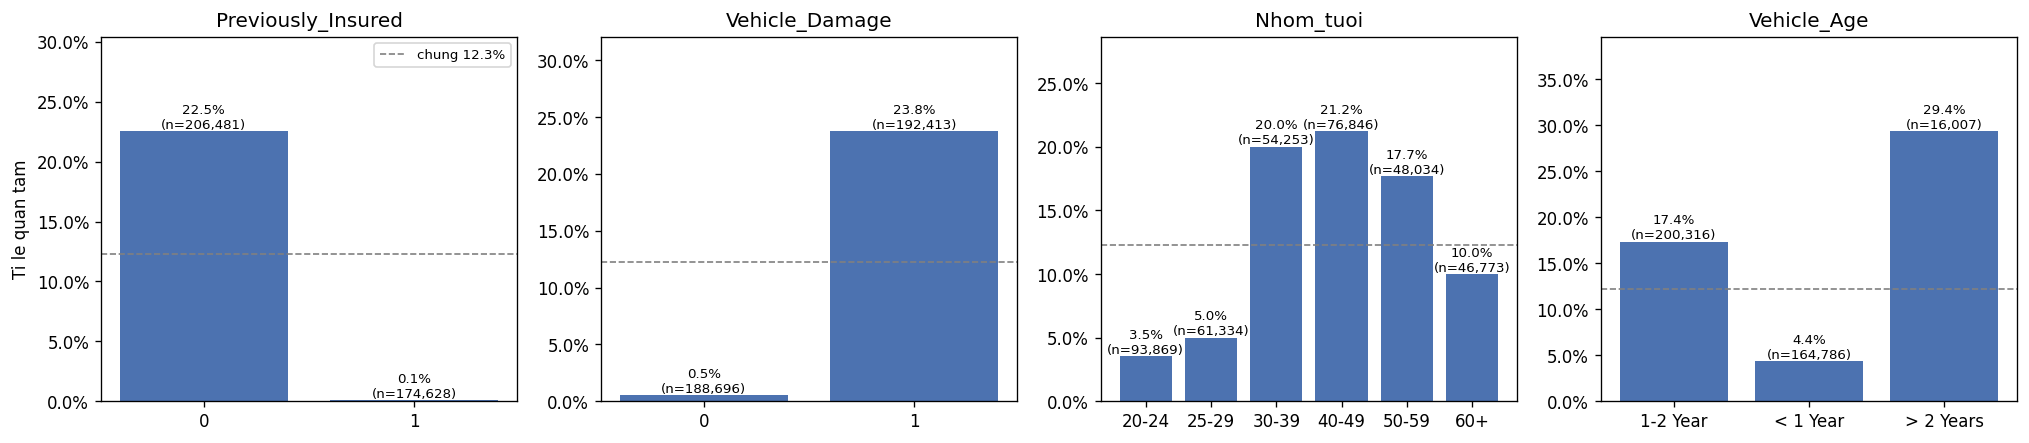

Previously_Insured


,so_khach,ti_le_quan_tam,ti_trong
Previously_Insured,,,
0,206481,0.2255,0.5418
1,174628,0.0009,0.4582


Vehicle_Damage


,so_khach,ti_le_quan_tam,ti_trong
Vehicle_Damage,,,
0,188696,0.0052,0.4951
1,192413,0.2377,0.5049


Nhom_tuoi


,so_khach,ti_le_quan_tam,ti_trong
Nhom_tuoi,,,
20-24,93869,0.0353,0.2463
25-29,61334,0.0499,0.1609
30-39,54253,0.2001,0.1424
40-49,76846,0.2124,0.2016
50-59,48034,0.1769,0.1260
60+,46773,0.0997,0.1227


Vehicle_Age


,so_khach,ti_le_quan_tam,ti_trong
Vehicle_Age,,,
1-2 Year,200316,0.1738,0.5256
< 1 Year,164786,0.0437,0.4324
> 2 Years,16007,0.2937,0.0420


Cheo Previously_Insured x Vehicle_Damage


so_khach  ti_le_quan_tam
Previously_Insured Vehicle_Damage                          
0                  0                  23990          0.0379
                   1                 182491          0.2501
1                  0                 164706          0.0004
                   1                   9922          0.0087

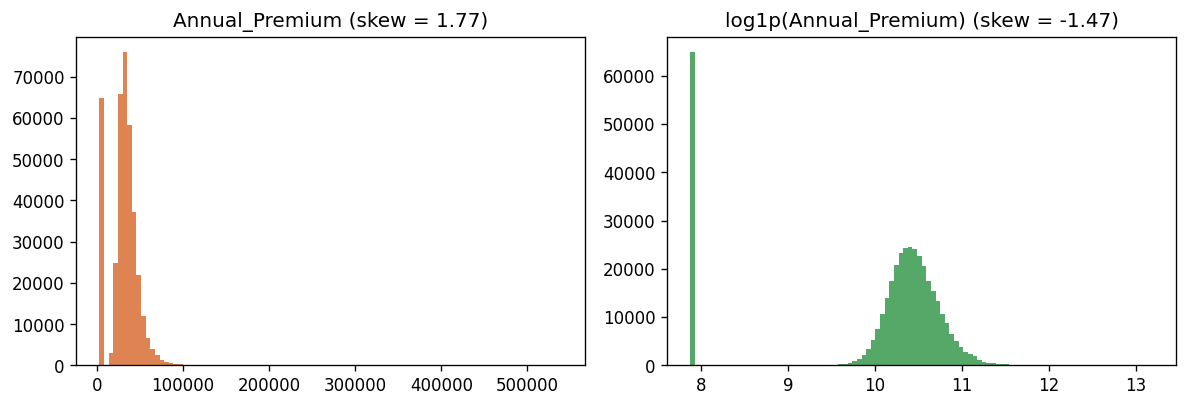

In [3]:
eda = T.run_eda(data["df"])
display(Image(R / "eda_ti_le_quan_tam.png"))
for k in ["Previously_Insured", "Vehicle_Damage", "Nhom_tuoi", "Vehicle_Age"]:
    print(k); display(eda[k])
print("Cheo Previously_Insured x Vehicle_Damage"); display(eda["Previously_Insured_x_Vehicle_Damage"])
display(Image(R / "eda_annual_premium.png"))

**Đọc kết quả:**

| Nhóm | Tỉ lệ quan tâm | Nhận xét |
|---|---:|---|
| `Previously_Insured = 1` (45,8% khách) | **0,09%** | Đã có bảo hiểm xe thì gần như không bao giờ mua |
| `Previously_Insured = 0` | 22,5% | |
| `Vehicle_Damage = Yes` | **23,8%** | Xe từng hư hỏng thì quan tâm gấp ~46 lần |
| `Vehicle_Damage = No` | 0,5% | |
| Tuổi 20–29 | 3,5–5,0% | Người trẻ ít quan tâm |
| Tuổi 30–59 | 17,7–21,2% | Nhóm mục tiêu |
| Xe > 2 năm | 29,4% (chỉ 4,2% khách) | |

* **Bảng chéo:** nhóm *chưa có bảo hiểm xe **và** xe từng hư hỏng* (182.491 khách, 47,9%) có tỉ lệ **25,0%**. Ba
  nhóm còn lại chỉ 0,04–3,8%. Chỉ với 2 cột nhị phân đã loại được hơn nửa danh sách gần như không mất người quan tâm.
  Phần khó của bài nằm **bên trong** nhóm 25% này.
* `Previously_Insured` **không phải rò rỉ**: đây là trạng thái trước cuộc gọi. Tỉ lệ 0,09% (không phải 0%) cũng cho
  thấy biến không được suy ra từ nhãn.
* `Annual_Premium`: độ lệch (skew) **1,77** giảm còn **−1,47** sau `log1p`. Đuôi trái sau log đến từ cụm ~17% khách có
  phí tối thiểu 2.630. Hai đuôi này nhỏ hơn nhiều so với đuôi phải cực dài ban đầu (max 540k). Sau đó StandardScaler
  đưa về thang đo chung.

## 4. ⭐ Baseline bắt buộc: LightGBM

**Logic code (`fit_lgbm`, `run_tree_baselines`):** chạy 2 phiên bản để đo cả **kết quả** lẫn **công sức**:

```python
# 1) Mac dinh: khong chinh gi (100 cay, learning_rate 0.1)
lgb.LGBMClassifier().fit(X_tr, y_tr, categorical_feature=["Region_Code", "Policy_Sales_Channel"])
# 2) Tinh chinh nhe: learning_rate nho + nhieu cay + early stopping theo average_precision tren VAL
lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.03, min_child_samples=200, subsample=0.8, ...)
   .fit(..., eval_set=[(X_val, y_val)], eval_metric="average_precision",
        callbacks=[lgb.early_stopping(200)])
```

* Cây **không cần** chuẩn hoá hay log: cây chỉ so sánh ngưỡng, nên biến đổi đơn điệu không đổi kết quả.
  `tree_matrix()` chỉ đổi `Vehicle_Age` thành 0/1/2.
* `categorical_feature`: LightGBM gom các mức của biến phân loại thành 2 nhóm tại mỗi lần chia (sắp xếp theo
  gradient). Không cần one-hot 155 cột.
* "Cùng dữ liệu" ở đây là cùng các dòng train/val/test và cùng các cột gốc. Mỗi model nhận dạng biểu diễn hợp với nó.

In [4]:
tree_table, trees = T.run_tree_baselines(data)
display(tree_table)
print("Do quan trong (gain) cua LightGBM tinh chinh:")
display(pd.read_csv(R / "lgbm_feature_importance.csv", index_col=0).T)

[lgbm] LightGBM (mac dinh): 100 cay, 4.2s, PR-AUC val 0.3707 test 0.3661


[lgbm] LightGBM (tinh chinh + early stopping): 193 cay, 9.7s, PR-AUC val 0.3735 test 0.3692


,mo_hinh,so_cay,thoi_gian_train_s,pr_auc_val,pr_auc_test,roc_auc_test
0,LightGBM (mac dinh),100,4.2268,0.3707,0.3661,0.8586
1,LightGBM (tinh chinh + early stopping),193,9.6673,0.3735,0.3692,0.8594


Do quan trong (gain) cua LightGBM tinh chinh:


,Vehicle_Damage,Previously_Insured,Policy_Sales_Channel,Age,Region_Code,Annual_Premium,Vintage,Vehicle_Age,Gender,Driving_License
ti_trong_gain,0.4533,0.3303,0.0917,0.0642,0.0341,0.0105,0.0070,0.0057,0.0023,0.0008


**Đọc kết quả:**

| | Số cây | Thời gian | PR-AUC val | PR-AUC test | ROC-AUC test |
|---|---:|---:|---:|---:|---:|
| LightGBM **mặc định** | 100 | **4,2 s** | 0,3707 | 0,3661 | 0,8586 |
| LightGBM tinh chỉnh + early stopping | 193 | 9,7 s | **0,3735** | **0,3692** | 0,8594 |

* Đây là "vạch xuất phát" mà MLP phải vượt. **Không chỉnh gì**, LightGBM đã đạt PR-AUC test 0,366 trong 4 giây.
  Tinh chỉnh nhẹ chỉ thêm 0,003.
* PR-AUC ~0,37 cao hơn mức tham chiếu của đề (0,30–0,35). Mức trần của bộ dữ liệu này khá thấp: ROC-AUC 0,86 nhưng
  lớp dương hiếm và trộn lẫn với lớp âm trong nhóm "chưa có bảo hiểm + xe hỏng".
* Độ quan trọng (gain): `Vehicle_Damage` 45%, `Previously_Insured` 33%, `Policy_Sales_Channel` 9%, `Age` 6%,
  `Region_Code` 3%. **Kênh bán là biến mạnh thứ ba**, nên cách mã hoá nó (bước 10) đáng để thử.

## Hàm huấn luyện dùng chung: `fit_keras`

Mọi thí nghiệm MLP đều đi qua một hàm, nên chỉ khác nhau ở **đúng** tham số đang so sánh:

```python
tf.keras.utils.set_random_seed(seed)          # cung khoi tao trong so + cung thu tu batch
net = M.build_mlp(n_features, hidden, dropout, batchnorm)        # hoac build_embedding_mlp(...)
M.compile_model(net)                           # Adam(1e-3) + binary_crossentropy + AUC(PR) + Recall
cw  = compute_class_weight("balanced", ...)    # {0: 0.57, 1: 4.08} neu dung class_weight
net.fit(X_tr, y_tr, batch_size=2048, epochs=100, validation_data=(X_val, y_val),
        class_weight=cw, callbacks=M.make_callbacks(ckpt))
```

**Ba callback** (`model.make_callbacks`):

| Callback | Theo dõi | Làm gì |
|---|---|---|
| `EarlyStopping(patience=10, restore_best_weights=True)` | `val_pr_auc` (max) | 10 epoch không cải thiện thì dừng, rồi **khôi phục trọng số của epoch tốt nhất** |
| `ReduceLROnPlateau(factor=0.5, patience=5)` | `val_loss` | 5 epoch loss không giảm thì giảm learning rate một nửa. Dùng loss vì loss mượt hơn PR-AUC |
| `ModelCheckpoint(save_best_only=True)` | `val_pr_auc` (max) | Ghi model tốt nhất ra `models/runs/<ten>.keras`. Model cuối được copy thành `models/best.keras` |

**Đầu ra 1 neuron + sigmoid** cho bài nhị phân: ra thẳng P(quan tâm). 2 neuron + softmax cho cùng kết quả nhưng
thừa một bộ tham số.

**PR-AUC báo cáo** là `sklearn.average_precision_score` trên dự đoán của model đã khôi phục trọng số tốt nhất.
`AUC(curve="PR")` của Keras chỉ dùng để theo dõi trong lúc train: nó xấp xỉ bằng 500 ngưỡng nên lệch nhẹ so với sklearn.
`batch_size=2048` vì 267k dòng train: batch nhỏ thì mỗi epoch rất chậm trên CPU mà không được lợi gì rõ rệt.

## 5–6. MLP cơ bản vs thêm Dropout + BatchNorm

**Logic code (`run_dropout_bn`):** cùng kiến trúc (128, 64), cùng seed, cùng class_weight. Chỉ khác:

```python
fit_keras("co_ban_128_64",     data, (128, 64), dropout=0,          batchnorm=False)
fit_keras("dropout_bn_128_64", data, (128, 64), dropout=(0.3, 0.2), batchnorm=True)
```

* **BatchNorm**: chuẩn hoá đầu ra mỗi lớp ẩn theo từng batch (trung bình 0, phương sai 1, rồi co giãn bằng γ, β học
  được). Giúp gradient ổn định nên có thể dùng learning rate lớn hơn.
* **Dropout(p)**: khi train, tắt ngẫu nhiên tỉ lệ p neuron ở mỗi bước. Mạng không dựa được vào vài neuron riêng lẻ,
  nên khó học thuộc lòng. Khi predict thì Dropout tắt.

In [5]:
dbn_table, dbn = T.run_dropout_bn(data)
dbn_table

[mlp] co_ban_128_64                params= 36,097 epochs= 21 (best  11)   54.1s | PR-AUC val 0.3642 test 0.3644


[mlp] dropout_bn_128_64            params= 36,865 epochs= 45 (best  35)  195.8s | PR-AUC val 0.3685 test 0.3662


,ten,kien_truc,dropout_bn,class_weight,ma_hoa,so_dau_vao,so_tham_so,so_epoch,epoch_tot_nhat,thoi_gian_train_s,s_moi_epoch,pr_auc_val,pr_auc_test,roc_auc_test
0,co_ban_128_64,"(128, 64)",False,True,one-hot,216,36097,21,11,54.0641,2.5745,0.3642,0.3644,0.8574
1,dropout_bn_128_64,"(128, 64)",True,True,one-hot,216,36865,45,35,195.7680,4.3504,0.3685,0.3662,0.8589


**Đọc kết quả** (cùng (128, 64), cùng class_weight):

| | Tham số | Epoch (tốt nhất) | Thời gian | PR-AUC val | PR-AUC test |
|---|---:|---:|---:|---:|---:|
| MLP cơ bản | 36.097 | 21 (11) | 54 s | 0,3642 | 0,3644 |
| + Dropout + BatchNorm | 36.865 | 45 (35) | 196 s | **0,3685** | **0,3662** |

* Dropout + BatchNorm tăng **+0,004** PR-AUC val (+0,002 test) và chỉ thêm 768 tham số (γ, β, mean, var của BatchNorm).
* Đổi lại, thời gian train gấp ~3,6 lần: mỗi epoch chậm hơn (BatchNorm) và cần nhiều epoch hơn mới dừng (Dropout làm
  quá trình học chậm lại).
* Cả hai **vẫn thấp hơn LightGBM mặc định** (0,3707 val).

## 7. Đường học: loss và PR-AUC theo epoch

**Logic code (`plot_learning_curves`):** `history.history` của Keras lưu mọi metric theo epoch (`loss`, `pr_auc`,
`val_loss`, `val_pr_auc`, `learning_rate`...). Vẽ train và val trên cùng trục, đường đứt là epoch tốt nhất (epoch mà
EarlyStopping khôi phục).

**Cách đọc để chẩn đoán:**
* **Overfit:** train tiếp tục tốt lên, val đi ngang rồi xấu đi → khoảng cách train–val mở rộng.
* **Underfit:** cả train và val đều kém và vẫn đang đi lên khi dừng.
* Lưu ý: metric **train** được tính trong lúc train, **có** Dropout và **có** class_weight trong loss. Vì vậy với mạng có
  Dropout, train có thể *thấp hơn* val, và loss train/val không so trực tiếp được khi dùng class_weight (loss train
  được nhân trọng số, val thì không). Xu hướng theo epoch mới là thứ cần nhìn.

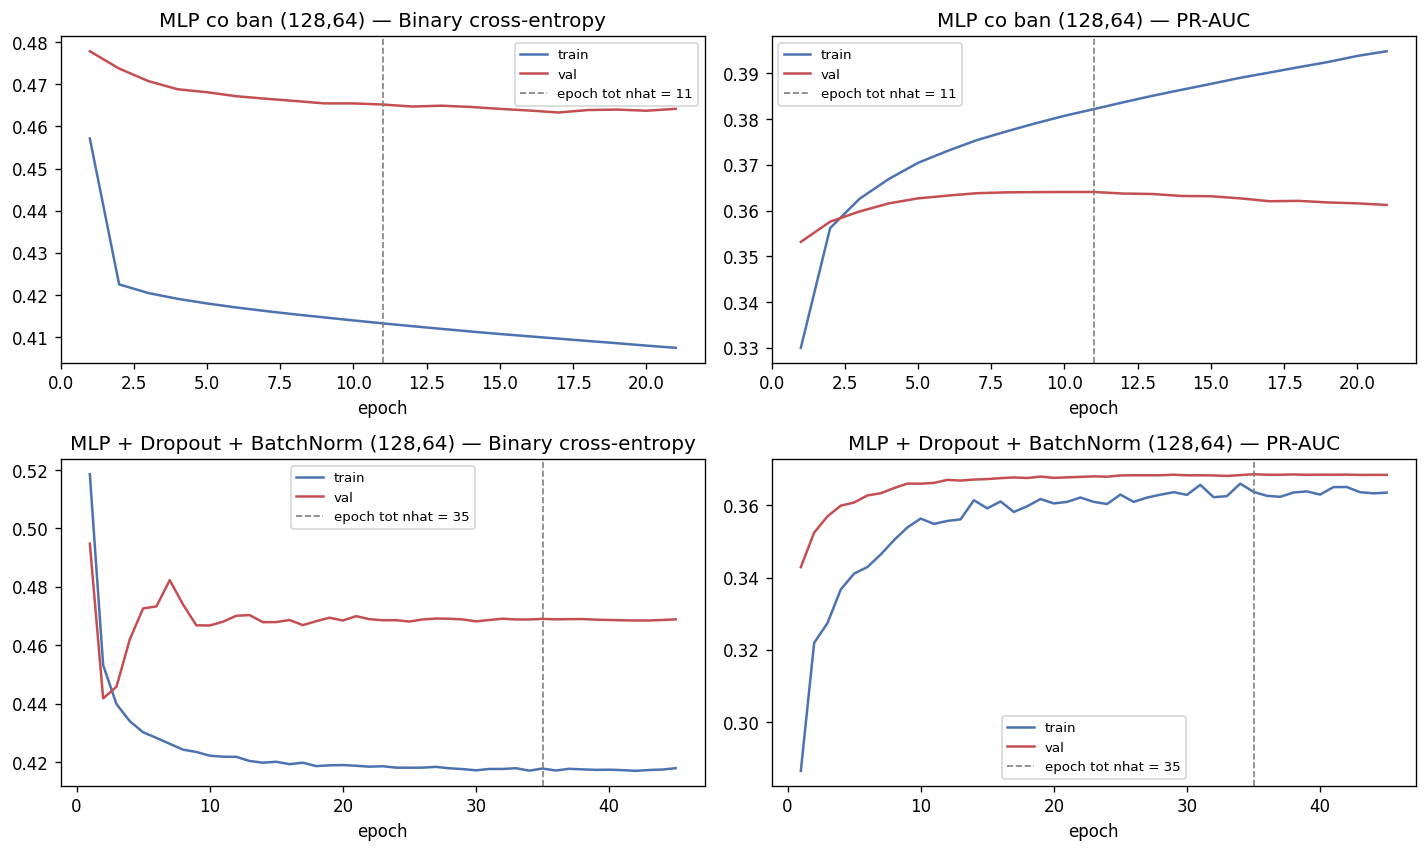

MLP co ban - 5 epoch cuoi:


,loss,pr_auc,recall,val_loss,val_pr_auc,val_recall,learning_rate
17,0.4096,0.3902,0.9312,0.4633,0.3620,0.9151,0.0010
18,0.4091,0.3914,0.9315,0.4639,0.3621,0.9144,0.0010
19,0.4085,0.3925,0.9312,0.4640,0.3618,0.9131,0.0010
20,0.4080,0.3938,0.9312,0.4637,0.3616,0.9108,0.0010
21,0.4074,0.3948,0.9312,0.4642,0.3612,0.9098,0.0010


In [6]:
T.plot_learning_curves({"MLP co ban (128,64)": dbn["co_ban"],
                        "MLP + Dropout + BatchNorm (128,64)": dbn["dropout_bn"]})
display(Image(R / "learning_curves.png"))
h = dbn["co_ban"]["history"]
print("MLP co ban - 5 epoch cuoi:"); display(h.tail(5))

**Đọc kết quả, chẩn đoán:**

* **MLP cơ bản: overfit rõ ràng và sớm.** PR-AUC **train** tăng đều từ 0,33 lên **0,395**, loss train giảm liên tục.
  Nhưng PR-AUC **val** đạt đỉnh **0,364 ở epoch 11** rồi **giảm dần** (0,361 ở epoch 21). Khoảng cách train–val mở
  rộng mỗi epoch. Mạng 36k tham số bắt đầu học thuộc các tổ hợp hiếm của 155 kênh × 53 vùng. EarlyStopping dừng ở epoch
  21 và khôi phục trọng số epoch 11. **Không có EarlyStopping thì model càng train càng tệ.**
* **Có Dropout + BatchNorm: hết overfit.** PR-AUC val tăng đều rồi đi ngang ở ~0,368 (không giảm). PR-AUC train
  (0,363) **thấp hơn** val. Đây không phải lỗi: metric train được đo khi Dropout đang tắt 20–30% neuron. ReduceLROnPlateau
  giảm learning rate liên tục từ 1e-3 xuống **1e-5** (val_loss ngừng giảm từ epoch ~2). Model "tinh chỉnh" chậm thêm
  ~30 epoch chỉ để được +0,001.
* **Loss val cao hơn loss train ở cả hai** (0,46 so với 0,41–0,42) một phần vì class_weight: loss train được nhân
  trọng số, val thì không. Không nên đọc khoảng cách loss tuyệt đối. Khoảng cách **PR-AUC** mới là tín hiệu overfit.
* Không có dấu hiệu underfit: cả hai đạt val ~0,36–0,37, gần mức của LightGBM.

## 8. Thử 3 kiến trúc: (64) · (128, 64) · (256, 128, 64)

**Logic code (`run_architectures`):** cả 3 đều có BatchNorm + Dropout, cùng class_weight, cùng seed:

```python
ARCHS    = {"(64)": (64,), "(128,64)": (128, 64), "(256,128,64)": (256, 128, 64)}
DROPOUTS = {"(64)": (0.3,), "(128,64)": (0.3, 0.2), "(256,128,64)": (0.3, 0.3, 0.2)}
```

Kiến trúc được chọn bằng `best_by_val()`: PR-AUC **val** cao nhất. Số tham số tính bằng `model.count_params()`.
Phần lớn tham số nằm ở lớp đầu: (~220 đầu vào) × (số neuron lớp 1).

[mlp] kien_truc_64                 params= 14,209 epochs= 30 (best  20)   71.6s | PR-AUC val 0.3672 test 0.3630


[mlp] kien_truc_128_64             params= 36,865 epochs= 45 (best  35)  174.8s | PR-AUC val 0.3685 test 0.3662


[mlp] kien_truc_256_128_64         params= 98,561 epochs= 54 (best  44)  259.5s | PR-AUC val 0.3670 test 0.3674


Kien truc chon theo VAL: (128,64)


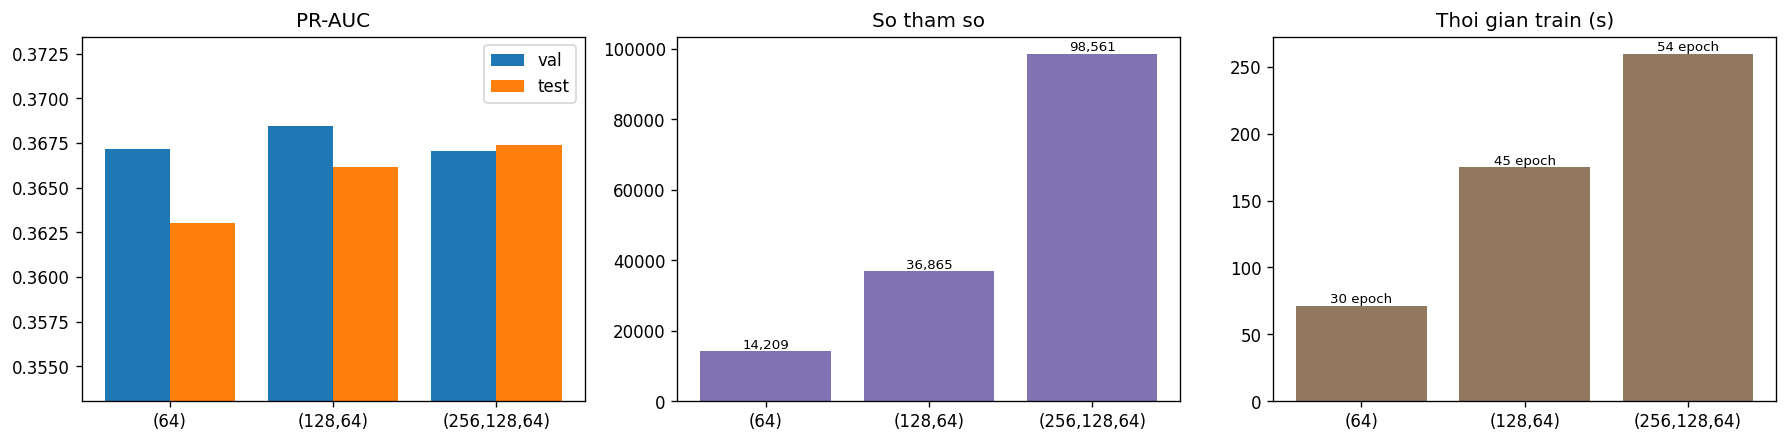

,ten_kien_truc,ten,kien_truc,dropout_bn,class_weight,ma_hoa,so_dau_vao,so_tham_so,so_epoch,epoch_tot_nhat,thoi_gian_train_s,s_moi_epoch,pr_auc_val,pr_auc_test,roc_auc_test
0,(64),kien_truc_64,"(64,)",True,True,one-hot,216,14209,30,20,71.5547,2.3852,0.3672,0.3630,0.8585
1,"(128,64)",kien_truc_128_64,"(128, 64)",True,True,one-hot,216,36865,45,35,174.8297,3.8851,0.3685,0.3662,0.8589
2,"(256,128,64)",kien_truc_256_128_64,"(256, 128, 64)",True,True,one-hot,216,98561,54,44,259.5190,4.8059,0.3670,0.3674,0.8589


In [7]:
arch_table, archs = T.run_architectures(data)
arch = T.best_by_val(archs)
print("Kien truc chon theo VAL:", arch)
display(Image(R / "kien_truc_comparison.png"))
arch_table

**Đọc kết quả:**

| Kiến trúc | Tham số | Epoch (tốt nhất) | Thời gian | PR-AUC val | PR-AUC test |
|---|---:|---:|---:|---:|---:|
| (64) | 14.209 | 30 (20) | 72 s | 0,3672 | 0,3630 |
| **(128, 64)** | 36.865 | 45 (35) | 175 s | **0,3685** | 0,3662 |
| (256, 128, 64) | 98.561 | 54 (44) | 260 s | 0,3670 | **0,3674** |

* **Ba kiến trúc gần như bằng nhau:** chênh lệch val chỉ **0,0015** dù số tham số chênh **7 lần**. Thứ hạng trên val
  và test còn **ngược nhau** ((256,128,64) xấu nhất trên val nhưng tốt nhất trên test). Đây là dấu hiệu chênh lệch nằm
  trong vùng nhiễu.
* Chọn (128, 64) theo val, đúng quy tắc. Bài học: với 10 đặc trưng gốc, **độ sâu không giúp gì**. Thông tin ở đây ít
  và phần lớn nằm trong vài tương tác đơn giản. Mạng sâu hơn chỉ tốn thời gian train hơn (72 s → 260 s).

## 9. class_weight vs không dùng

**Logic code (`run_class_weight`):** tái dùng run có class_weight của kiến trúc đã chọn (từ bước 8), chỉ train thêm
bản **không** class_weight. Với `'balanced'`:

```
w_k = n_mau / (2 * n_mau_lop_k)   ->   {0: 0.57, 1: 4.08}
```

Mỗi mẫu "quan tâm" đóng góp vào loss gấp ~7 lần mẫu "không quan tâm". Bảng in thêm:
* `xac_suat_tb_test`: trung bình xác suất dự đoán. Model **hiệu chỉnh tốt** thì con số này ≈ tỉ lệ thật 12,3%.
* `recall_nguong_0.5`, `ti_le_du_doan_1_nguong_0.5`: hành vi khi cắt ở ngưỡng mặc định 0,5.

**Điều cần kiểm chứng:** PR-AUC chỉ phụ thuộc **thứ tự** xếp hạng. class_weight chủ yếu dịch chuyển xác suất lên
cao, nên có thể **không** cải thiện xếp hạng.

In [8]:
cw_table, cws = T.run_class_weight(data, arch, archs[arch])
use_cw = cws["co class_weight"]["pr_auc_val"] >= cws["khong class_weight"]["pr_auc_val"]
best_oh = cws["co class_weight" if use_cw else "khong class_weight"]
print("Dung class_weight (chon theo VAL)?", use_cw)
cw_table

[mlp] khong_class_weight_128_64    params= 36,865 epochs= 32 (best  22)  113.2s | PR-AUC val 0.3694 test 0.3662


[cw] cw={0: 0.569839669513284, 1: 4.079627477367262}


Dung class_weight (chon theo VAL)? False


,cau_hinh,ten,kien_truc,dropout_bn,class_weight,ma_hoa,so_dau_vao,so_tham_so,so_epoch,epoch_tot_nhat,thoi_gian_train_s,s_moi_epoch,pr_auc_val,pr_auc_test,roc_auc_test,xac_suat_tb_test,ti_le_thuc_test,recall_nguong_0.5,ti_le_du_doan_1_nguong_0.5
0,co class_weight,kien_truc_128_64,"(128, 64)",True,True,one-hot,216,36865,45,35,174.8297,3.8851,0.3685,0.3662,0.8589,0.3337,0.1226,0.9352,0.4037
1,khong class_weight,khong_class_weight_128_64,"(128, 64)",True,False,one-hot,216,36865,32,22,113.2137,3.5379,0.3694,0.3662,0.8585,0.1183,0.1226,0.0014,0.0005


**Đọc kết quả** (cùng (128, 64) + Dropout + BatchNorm):

| | PR-AUC val | PR-AUC test | Xác suất TB (thật 12,3%) | Recall @0,5 | % dự đoán "1" @0,5 | Thời gian |
|---|---:|---:|---:|---:|---:|---:|
| class_weight {0: 0,57, 1: 4,08} | 0,3685 | 0,3662 | **0,334** | 93,5% | 40,4% | 175 s |
| **không** class_weight | **0,3694** | 0,3662 | **0,118** | 0,1% | 0,05% | 113 s |

* **PR-AUC không đổi** (test bằng nhau đến 4 chữ số). Đúng như dự đoán: class_weight **không làm xếp hạng tốt hơn**. Nó
  chỉ đẩy toàn bộ xác suất lên cao. Với bài **xếp hạng** để gọi top 3.000 thì class_weight vô ích.
* Nó **làm hỏng hiệu chỉnh xác suất:** trung bình dự đoán 33% trong khi thực tế 12,3%. Nếu đội kinh doanh dùng xác suất
  để ước tính "gọi 3.000 người được bao nhiêu khách", con số sẽ bị thổi phồng ~2,7 lần. Bản không class_weight có
  trung bình **11,8%**, gần đúng.
* Ngưỡng 0,5 là chỗ hai bản khác nhau rõ nhất: có class_weight thì recall 93% nhưng gắn nhãn "quan tâm" cho 40% khách.
  Không có thì gần như không ai vượt 0,5. Cả hai cho thấy **ngưỡng 0,5 vô nghĩa** ở bài này. Ngưỡng phải chọn theo
  ngân sách gọi (bước 11).
* Chọn **không** class_weight (val cao hơn một chút, train nhanh hơn, xác suất đúng thang).

## 10. ⭐ Embedding cho `Region_Code` và `Policy_Sales_Channel`

**Logic code (`model.build_embedding_mlp`)**, dùng Functional API vì có 3 đầu vào:

```python
in_dense   = Input(shape=(10,))                    # so + nhi phan + one-hot Vehicle_Age
in_region  = Input(shape=(), dtype="int32")        # chi so 0..n_region-1
in_channel = Input(shape=(), dtype="int32")        # chi so 0..n_channel-1
e_region   = Embedding(n_region, 8)(in_region)     # bang tra cuu n_region x 8, hoc bang backprop
e_channel  = Embedding(n_channel, 12)(in_channel)  # bang tra cuu n_channel x 12
x = Concatenate()([in_dense, e_region, e_channel]) # 10 + 8 + 12 = 30 cot
x = Dense -> BatchNorm -> Dropout ...  -> Dense(1, sigmoid)
```

* **Về toán học**, one-hot × ma trận trọng số lớp Dense đầu tiên chính là "lấy 1 hàng". Embedding làm đúng việc đó
  nhưng tách thành bước riêng, **ép mỗi mã về vector d chiều nhỏ** (8 hoặc 12) rồi mới vào lớp Dense. Số tham số cho 2
  biến giảm từ `(53+155) × n1` xuống `(n_region×8 + n_channel×12) + (8+12) × n1` (n1 = số neuron lớp đầu). Các mã có
  hành vi giống nhau sẽ có vector gần nhau.
* Đầu vào không còn ma trận 220 cột chủ yếu là số 0.
* Kiến trúc và class_weight lấy theo lựa chọn ở bước 8–9 để so sánh công bằng: chỉ khác **cách mã hoá**.

Sau khi train, `channel_embedding_neighbors()` lấy ma trận `emb_channel`, chuẩn hoá từng hàng rồi tìm kênh có cosine
lớn nhất với mỗi kênh lớn. Mục đích là kiểm tra embedding có học được điều gì có nghĩa không.

[mlp] embedding_128_64             params= 14,773 epochs= 36 (best  26)  109.4s | PR-AUC val 0.3711 test 0.3683


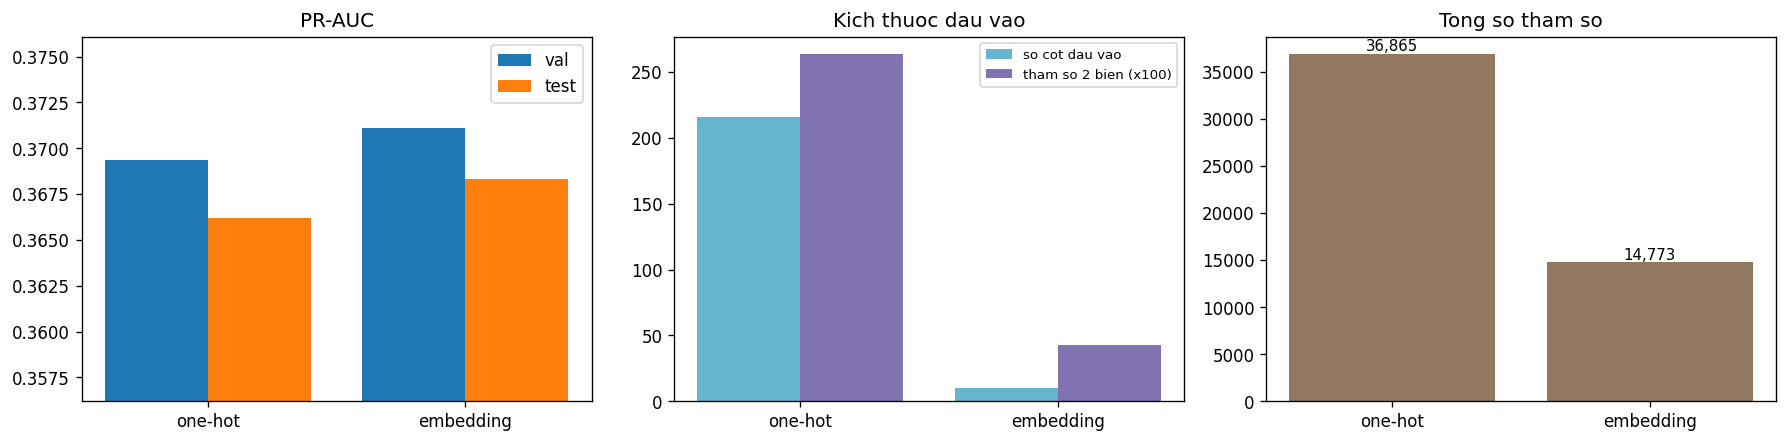

,cach_ma_hoa,ten,kien_truc,dropout_bn,class_weight,ma_hoa,so_dau_vao,so_tham_so,so_epoch,epoch_tot_nhat,thoi_gian_train_s,s_moi_epoch,pr_auc_val,pr_auc_test,roc_auc_test,tham_so_cho_2_bien_nhieu_muc
0,one-hot,khong_class_weight_128_64,"(128, 64)",True,False,one-hot,216,36865,32,22,113.2137,3.5379,0.3694,0.3662,0.8585,26368
1,embedding,embedding_128_64,"(128, 64)",True,False,embedding,10,14773,36,26,109.4165,3.0393,0.3711,0.3683,0.8589,4276


Kenh ban lon nhat va kenh 'gan nhat' trong khong gian embedding:


,kenh,so_khach_train,ti_le_quan_tam,kenh_gan_nhat,cosine,ti_le_quan_tam_kenh_gan_nhat
0,152,94517,0.0290,73,0.8702,0.0833
1,26,55696,0.2000,9,0.8603,0.1220
2,124,51798,0.1886,130,0.7644,0.1333
3,160,15217,0.0227,151,0.9317,0.0276
4,156,7409,0.2162,145,0.7850,0.1333
5,122,6928,0.1715,109,0.5596,0.1429
6,157,4679,0.2684,20,0.8921,0.1429
7,154,4176,0.2404,155,0.8362,0.3212


MLP cuoi (chon theo VAL): embedding_128_64
[save] embedding_128_64.keras -> models/best.keras


In [9]:
emb_table, embs = T.run_embedding(data, arch, use_cw, best_oh)
display(Image(R / "embedding_vs_onehot.png"))
display(emb_table)
print("Kenh ban lon nhat va kenh 'gan nhat' trong khong gian embedding:")
display(T.channel_embedding_neighbors(data, embs["embedding"]))
use_emb = embs["embedding"]["pr_auc_val"] > best_oh["pr_auc_val"]
final = embs["embedding"] if use_emb else best_oh
print("MLP cuoi (chon theo VAL):", final["ten"])
T.save_final_model(final)

**Đọc kết quả** (cùng (128, 64) + Dropout + BatchNorm, không class_weight):

| | Cột đầu vào | Tham số cho 2 biến nhiều mức | Tổng tham số | Thời gian | PR-AUC val | PR-AUC test |
|---|---:|---:|---:|---:|---:|---:|
| One-hot | 216 | 26.368 | 36.865 | 113 s | 0,3694 | 0,3662 |
| **Embedding** (8 + 12 chiều) | 10 + 2 chỉ số | **4.276** | **14.773** | 109 s | **0,3711** | **0,3683** |

* Embedding **cải thiện cả val (+0,0017) lẫn test (+0,0021)** với **ít hơn 2,5 lần tham số** (phần dành cho 2 biến
  giảm 6 lần). Đây là cấu hình MLP tốt nhất, được lưu vào `models/best.keras`.
* Lý do: one-hot cho mỗi kênh một bộ 128 trọng số riêng, nên kênh nhỏ (vài chục khách) có trọng số gần như ngẫu nhiên.
  Embedding ép các kênh chia sẻ không gian 12 chiều. Kênh có hành vi giống nhau dùng chung "hướng", và kênh quá hiếm
  được gộp vào "khác".
* **Embedding học được gì?** Bảng láng giềng cho thấy **một phần** có ý nghĩa. Kênh 160 (2,3% quan tâm) gần kênh 151
  (2,8%), và kênh 152 (kênh lớn nhất, 2,9%) gần kênh 73 (8,3%): các kênh "kém" tụ lại với nhau. Kênh 26/124/156 (19–22%)
  gần các kênh 12–13%. Không hoàn hảo: cosine trong 12 chiều còn mã hoá cả tương tác với tuổi và vùng, không chỉ tỉ lệ
  quan tâm.

## Kiểm tra độ dao động theo seed

**Vì sao cần:** các chênh lệch ở bước 5–10 chỉ cỡ phần nghìn PR-AUC. Trước khi kết luận "A tốt hơn B" phải biết
**chỉ đổi seed** thì kết quả lệch bao nhiêu. `run_seed_variance` train lại **MLP cuối** và **LightGBM tinh chỉnh** với
3 seed khác (1, 2, 3). Seed ảnh hưởng đến khởi tạo trọng số, thứ tự batch, Dropout (MLP) và lấy mẫu
`subsample/colsample` (LightGBM). Dữ liệu và cách chia giữ nguyên.

In [10]:
seeds = T.run_seed_variance(data, arch, use_cw, use_emb)
display(seeds)
seeds.groupby("mo_hinh")[["pr_auc_val", "pr_auc_test", "thoi_gian_train_s"]].agg(["mean", "std"])

                    pr_auc_val        pr_auc_test       
                          mean    std        mean    std
mo_hinh                                                 
LightGBM tinh chinh     0.3726 0.0002      0.3691 0.0008
MLP cuoi                0.3723 0.0003      0.3674 0.0013


,mo_hinh,seed,pr_auc_val,pr_auc_test,thoi_gian_train_s
0,MLP cuoi,1,0.3725,0.3690,103.6556
1,LightGBM tinh chinh,1,0.3724,0.3682,12.6401
2,MLP cuoi,2,0.3725,0.3666,196.6005
3,LightGBM tinh chinh,2,0.3726,0.3691,8.9131
4,MLP cuoi,3,0.3720,0.3667,111.0282
5,LightGBM tinh chinh,3,0.3728,0.3699,11.3114


pr_auc_val        pr_auc_test        thoi_gian_train_s        
                          mean    std        mean    std              mean     std
mo_hinh                                                                           
LightGBM tinh chinh     0.3726 0.0002      0.3691 0.0008           10.9548  1.8889
MLP cuoi                0.3723 0.0003      0.3674 0.0013          137.0948 51.6651

**Đọc kết quả** (3 seed: 1, 2, 3):

| | PR-AUC val (TB ± std) | PR-AUC test (TB ± std) | Thời gian train TB |
|---|---:|---:|---:|
| MLP cuối (embedding) | 0,3723 ± 0,0003 | 0,3674 ± **0,0013** | ~137 s |
| LightGBM tinh chỉnh | 0,3726 ± 0,0002 | **0,3691** ± 0,0008 | ~11 s |

* **Chỉ đổi seed, PR-AUC test của MLP đã dao động 0,0023** (0,3666–0,3690). Con số này **lớn hơn** phần lớn các chênh
  lệch ở bước 5–10: kiến trúc (≤ 0,0015), class_weight (0,000), Dropout+BN trên test (0,002). Chỉ có Embedding (+0,002)
  và Dropout+BN trên val (+0,004) ở mức ngang hoặc vượt nhiễu. Các kết luận "A tốt hơn B" ở trên cần đọc là **"không tệ
  hơn"**, không phải "chắc chắn tốt hơn".
* LightGBM **ổn định hơn** (std test 0,0008) và **cao hơn MLP trung bình 0,0017** trên test. Trên val hai bên bằng
  nhau (0,3726 so với 0,3723).

## 11. Precision@3000 và chọn ngưỡng

**Logic code (`run_precision_at_k`):**

* 3.000 cuộc/ngày trên 381.109 khách nghĩa là mỗi ngày gọi **top 0,79%** điểm cao nhất. Tập test (57.167 khách) là
  mẫu ngẫu nhiên 15% của toàn bộ khách, nên **top 0,79% của test (451 khách)** mô phỏng đúng danh sách gọi một ngày.
  Precision trên nhóm này là "Precision@3000" theo đúng nghĩa nghiệp vụ.
* **Ngưỡng chọn trên val:** `thr = diem cua khach thu ceil(0,79% x |val|)` trên val. Áp nguyên ngưỡng đó sang test
  để xem trong thực tế (dữ liệu mới) ngưỡng chọn ra bao nhiêu người và precision bao nhiêu. Không chọn ngưỡng
  bằng test.
* Cột `precision@3000_test (nghia den)`: lấy đúng 3.000 người đầu trên test. Đó là top 5,2% của test, tương ứng
  khoảng 7 ngày gọi đầu tiên, nên precision thấp hơn.
* `lift` = precision / tỉ lệ ngẫu nhiên 12,3%.

In [11]:
scores = {"MLP cuoi": (final["s_val"], final["s_test"]),
          "LightGBM tinh chinh": (trees["lgbm_tuned"]["s_val"], trees["lgbm_tuned"]["s_test"]),
          "LightGBM mac dinh": (trees["lgbm_default"]["s_val"], trees["lgbm_default"]["s_test"])}
p_table, p_curve = T.run_precision_at_k(data["y"]["val"], data["y"]["test"], scores)
display(p_table.set_index("mo_hinh").T)
p_curve.pivot(index="k", columns="mo_hinh", values="precision")

mo_hinh,MLP cuoi,LightGBM tinh chinh,LightGBM mac dinh
nguong_chon_tren_val,0.4368,0.4623,0.4583
so_khach_chon_o_test,471.0000,492.0000,483.0000
precision_tai_nguong_test,0.4756,0.4695,0.4783
precision_top451_test (=3000/ngay),0.4834,0.4789,0.4723
precision@3000_test (nghia den),0.4073,0.4170,0.4173
lift_3000/ngay,3.9436,3.9074,3.8532
khach_quan_tam_moi_ngay_uoc_tinh,"1,450.1108","1,436.8071","1,416.8514"
neu_goi_ngau_nhien,367.7121,367.7121,367.7121


mo_hinh,LightGBM mac dinh,LightGBM tinh chinh,MLP cuoi
k,,,
100,0.4100,0.4000,0.5100
250,0.4360,0.4680,0.4960
451,0.4723,0.4789,0.4834
1000,0.4530,0.4590,0.4550
2000,0.4310,0.4350,0.4270
3000,0.4173,0.4170,0.4073
5000,0.3966,0.3986,0.3944
7000,0.3840,0.3886,0.3860
10000,0.3658,0.3655,0.3646


**Đọc kết quả** (test, 1 ngày gọi = top 451 khách = 0,79%):

| | Ngưỡng (chọn trên val) | Số khách vượt ngưỡng ở test | Precision tại ngưỡng | **Precision 1 ngày (top 451)** | Precision@3000 nghĩa đen | Lift |
|---|---:|---:|---:|---:|---:|---:|
| MLP cuối | 0,437 | 471 | 47,6% | **48,3%** | 40,7% | 3,94× |
| LightGBM tinh chỉnh | 0,462 | 492 | 47,0% | 47,9% | **41,7%** | 3,91× |
| LightGBM mặc định | 0,458 | 483 | 47,8% | 47,2% | **41,7%** | 3,85× |

* **Giá trị kinh doanh:** gọi 3.000 người/ngày theo model thì khoảng **1.440–1.450** người quan tâm (~48%), so với
  **368** nếu gọi ngẫu nhiên. Tăng **gần 4 lần** với cả hai loại model.
* **Ngưỡng chọn trên val dùng được trên dữ liệu mới:** ở test nó chọn 471–492 người (mục tiêu 451) với precision
  47–48%, khớp với top-451 thật. Nếu triển khai, nên hiệu chỉnh lại ngưỡng định kỳ khi phân phối điểm thay đổi.
* MLP nhỉnh hơn ở top 451 (48,3% so với 47,9%) nhưng **thua** ở 3.000 người đầu (40,7% so với 41,7%). Trên 451 người,
  0,4 điểm % chỉ là **2 khách**, nằm trong nhiễu (sai số chuẩn của tỉ lệ ~48% trên 451 mẫu là ±2,4 điểm). Ở k = 100,
  MLP 51% so với LightGBM 40%, nhưng 100 mẫu thì sai số ±5 điểm và vùng này dao động mạnh (xem biểu đồ bên dưới).

## 12. ⭐ Bảng kết luận: MLP Keras vs LightGBM

**Logic code (`run_final_comparison`, `conclusion_rows`):** vẽ đường Precision–Recall và đường "precision theo ngân
sách gọi" trên **test** cho 3 model, rồi gộp vào một bảng gồm **hiệu quả** (PR-AUC val/test, trung bình ± độ lệch
theo seed, precision của danh sách 3.000/ngày) và **chi phí** (thời gian train, số lần train để chọn cấu hình, tiền
xử lý cần làm).

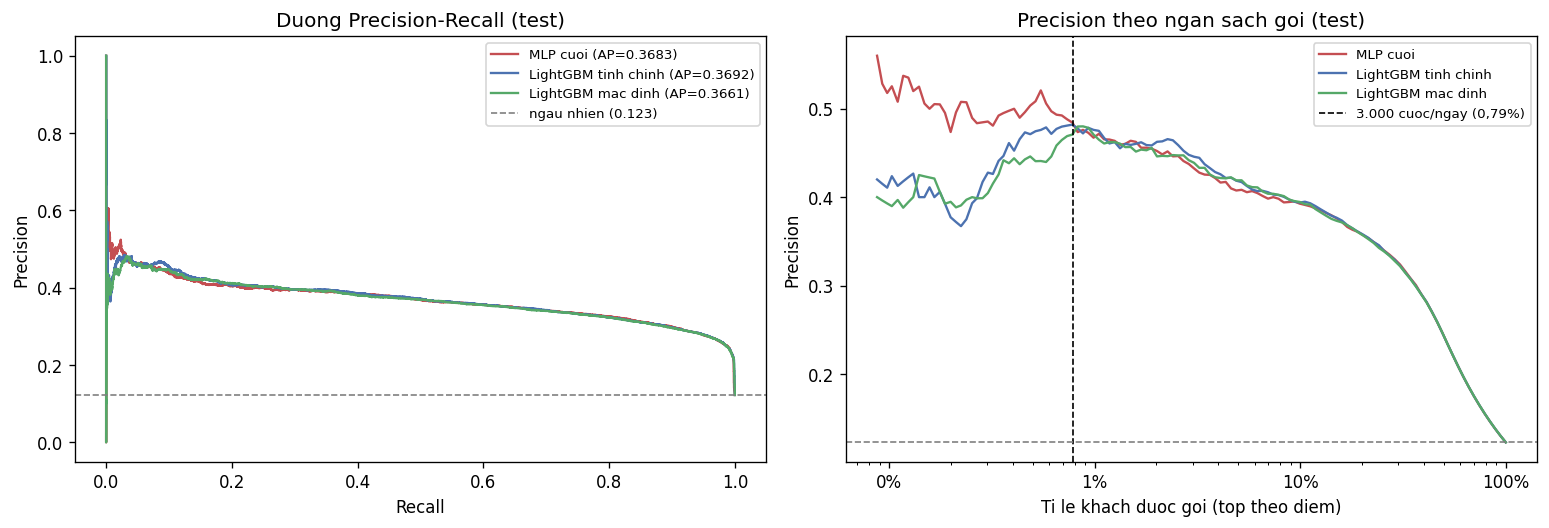

[save] reports/tom_tat.json


,mo_hinh,pr_auc_val,pr_auc_test,pr_auc_test_tb_3_seed,pr_auc_test_std_3_seed,precision_3000_ngay,thoi_gian_train_s,so_lan_train_de_chon,tien_xu_ly
0,LightGBM mac dinh,0.3707,0.3661,NaN,NaN,0.4723,4.2268,1,"khong (giu nguyen ma so, khai bao 2 cot catego..."
1,LightGBM tinh chinh,0.3735,0.3692,0.3691,0.0008,0.4789,9.6673,1,khong (+ early stopping tren val)
2,"MLP cuoi (128, 64) embedding",0.3711,0.3683,0.3674,0.0013,0.4834,109.4165,7,"log1p + StandardScaler + one-hot/Embedding, cl..."


In [12]:
concl = T.run_final_comparison(data["y"]["test"], {k: v[1] for k, v in scores.items()},
                               T.conclusion_rows(trees, final, seeds, p_table, n_mlp_runs=7))
display(Image(R / "pr_curve.png"))
T.save_summary(kien_truc_chon=arch, dung_class_weight=bool(use_cw), dung_embedding=bool(use_emb),
               baseline=tree_table, dropout_bn=dbn_table, kien_truc=arch_table, class_weight=cw_table,
               embedding=emb_table, precision_3000=p_table, ket_luan=concl)
concl

**Đọc kết quả, bảng kết luận MLP Keras vs LightGBM:**

| | PR-AUC test | PR-AUC test (3 seed) | Precision 1 ngày | Thời gian train | Số lần train để ra cấu hình | Tiền xử lý |
|---|---:|---:|---:|---:|---:|---|
| LightGBM mặc định | 0,3661 | — | 47,2% | **4 s** | **1** | không |
| **LightGBM tinh chỉnh** | **0,3692** | **0,3691 ± 0,0008** | 47,9% | 10 s | 1 | không |
| MLP (128,64) + Embedding | 0,3683 | 0,3674 ± 0,0013 | 48,3% | 109 s | 7 (+3 seed) | log1p, scale, one-hot, bảng mã, 3 callback |

**Đường PR của 3 model gần như trùng nhau** trên toàn bộ dải recall. Ba model xếp hạng khách gần như giống hệt nhau.

**Kết luận trung thực:**
1. **MLP không thắng được LightGBM** trên bộ dữ liệu này. Tốt nhất là **hoà**: MLP cuối kém LightGBM tinh chỉnh 0,0017
   PR-AUC trung bình, nhỏ nhưng nhất quán qua seed. Precision 1 ngày nhỉnh hơn 0,4 điểm, nhưng đó là nhiễu (2 khách).
2. **Chi phí hoàn toàn nghiêng về LightGBM:** train nhanh hơn **~10–25 lần** (4–10 s so với ~110 s), **không cần**
   chuẩn hoá, log hay one-hot, và cấu hình mặc định đã đạt 99% hiệu quả. Để MLP bắt kịp phải thử 7 cấu hình, thêm
   Dropout + BatchNorm, đổi sang Embedding và bỏ class_weight. Mỗi bước chỉ thêm vài phần nghìn.
3. **Với dữ liệu bảng ít cột (10 đặc trưng), chọn LightGBM.** Đúng với nhận định của đề. MLP đáng cân nhắc khi: có
   biến phân loại **rất** nhiều mức (hàng nghìn–triệu mã, khi đó Embedding thắng rõ), dữ liệu kết hợp văn bản hoặc ảnh,
   hoặc dùng làm thành phần trong ensemble/stacking (dự đoán của hai họ model khác nhau có thể bổ sung cho nhau).

## Kiểm tra `models/best.keras` nạp lại được

Nạp lại model từ đĩa, dự đoán trên test và so với điểm đã tính lúc train. Hai kết quả phải trùng nhau (sai khác chỉ ở
mức làm tròn float32).

In [13]:
reloaded = tf.keras.models.load_model(T.MODELS_DIR / "best.keras")
X_te = T.inputs(data["emb" if use_emb else "oh"]["test"], use_emb)
s = reloaded.predict(X_te, batch_size=8192, verbose=0).ravel()
print("Sai khac lon nhat so voi luc train:", float(np.abs(s - final["s_test"]).max()))
print("PR-AUC test cua model nap lai:", T.pr_auc(data["y"]["test"], s))
reloaded.summary()

Sai khac lon nhat so voi luc train: 0.0
PR-AUC test cua model nap lai: 0.3683269180534017


Model: "mlp_embedding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ region (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel             │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_region          │ (None, 8)         │        432 │ region[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_channel         │ (None, 12)        │      1,284 │ channel[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 30)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ emb_region[0][0], │
│                     │                   │            │ emb_channel[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h1_dense (Dense)    │ (None, 128)       │      3,968 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h1_bn               │ (None, 128)       │        512 │ h1_dense[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h1_drop (Dropout)   │ (None, 128)       │          0 │ h1_bn[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h2_dense (Dense)    │ (None, 64)        │      8,256 │ h1_drop[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h2_bn               │ (None, 64)        │        256 │ h2_dense[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h2_drop (Dropout)   │ (None, 64)        │          0 │ h2_bn[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prob (Dense)        │ (None, 1)         │         65 │ h2_drop[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,553 (170.13 KB)

 Trainable params: 14,389 (56.21 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 28,780 (112.43 KB)

**Đọc kết quả:** model nạp lại từ `models/best.keras` (định dạng Keras 3, lưu cả kiến trúc 3 đầu vào, trọng số, bảng
embedding và optimizer) cho dự đoán **trùng tuyệt đối** (sai khác 0,0) và PR-AUC test 0,3683 như lúc train. Lưu ý: để
dùng model cho khách mới vẫn phải áp **đúng** `Preprocessor` đã fit trên train (scaler + bảng mã kênh/vùng). Phần này
nằm ngoài file `.keras`, nên khi triển khai phải lưu kèm (ví dụ `joblib.dump(pre_emb, ...)`).